<a href="https://colab.research.google.com/github/ToluDan/ADA_SIWES_DTS_INTERNS/blob/main/Ada_Interns_E_commerce_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-commerce dataset form Kaggle

# New Section

Focus
1. EDA- Mr Dare
2. ML/Feature Engineering- Mr Dare & Paul
3. Visualization- Mr paul
4. Regression Analy & Seasonal Trend- Mr Vetinosa

.....check the part of the data set having missing values(first 100/200 data set and last 100/200 data set)

In [ ]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# Replace this with the actual path to your data file in Colab
df = pd.read_csv(r"/content/sample_data/E-commerce_data.csv.csv", encoding='latin-1')

In [ ]:
import os

# List files in the /content/ directory
files_in_content = os.listdir('/content/')
print(files_in_content)

['.config', 'sample_data']


In [ ]:
df.head(200)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
195,536388,22469,HEART OF WICKER SMALL,12,12/1/2010 9:59,1.65,16250.0,United Kingdom
196,536388,22242,5 HOOK HANGER MAGIC TOADSTOOL,12,12/1/2010 9:59,1.65,16250.0,United Kingdom
197,536389,22941,CHRISTMAS LIGHTS 10 REINDEER,6,12/1/2010 10:03,8.50,12431.0,Australia
198,536389,21622,VINTAGE UNION JACK CUSHION COVER,8,12/1/2010 10:03,4.95,12431.0,Australia


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.tail(200)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541709,581567,22625,RED KITCHEN SCALES,2,12/9/2011 11:56,8.50,16626.0,United Kingdom
541710,581567,23355,HOT WATER BOTTLE KEEP CALM,4,12/9/2011 11:56,4.95,16626.0,United Kingdom
541711,581567,21326,AGED GLASS SILVER T-LIGHT HOLDER,144,12/9/2011 11:56,0.55,16626.0,United Kingdom
541712,581567,21479,WHITE SKULL HOT WATER BOTTLE,4,12/9/2011 11:56,4.25,16626.0,United Kingdom
541713,581567,23356,LOVE HOT WATER BOTTLE,3,12/9/2011 11:56,5.95,16626.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [ ]:
print(f"Dataset loaded successfully from {df}!")

Dataset loaded successfully from        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custom

# Display basic information

In [ ]:
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")

Dataset Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


# Data preprocessing and cleaning

In [ ]:
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)



DATA PREPROCESSING


In [ ]:
print("\nMissing Values:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])


Missing Values:
Description      1454
CustomerID     135080
dtype: int64


In [ ]:
# Create visualizations
def create_eda_visualizations(df):
    """
    Create comprehensive visualizations for EDA
     """

In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [ ]:
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Customers: {df['CustomerID'].nunique():,}")
print(f"Total Products: {df['StockCode'].nunique() if 'StockCode' in df.columns else 'N/A':,}")
print(f"Total Revenue: $ {df['TotalAmount'].sum():,.2f}")
print(f"Average Order Value: $ {df['TotalAmount'].mean():.2f}")

Date Range: 1/10/2011 10:04 to 9/9/2011 9:52
Total Transactions: 541,909
Total Customers: 4,372
Total Products: 4,070
Total Revenue: $ 9,747,747.93
Average Order Value: $ 17.99


In [ ]:
#Conversion of Data
print("InvoiceDate dtype:", df['InvoiceDate'].dtype)
print("Sample of InvoiceDate values:")
print(df['InvoiceDate'].head())
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("After conversion - InvoiceDate dtype:", df['InvoiceDate'].dtype)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

InvoiceDate dtype: object
Sample of InvoiceDate values:
0    12/1/2010 8:26
1    12/1/2010 8:26
2    12/1/2010 8:26
3    12/1/2010 8:26
4    12/1/2010 8:26
Name: InvoiceDate, dtype: object
After conversion - InvoiceDate dtype: datetime64[ns]


InvoiceDate dtype: datetime64[ns]
Sample of InvoiceDate values:
0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


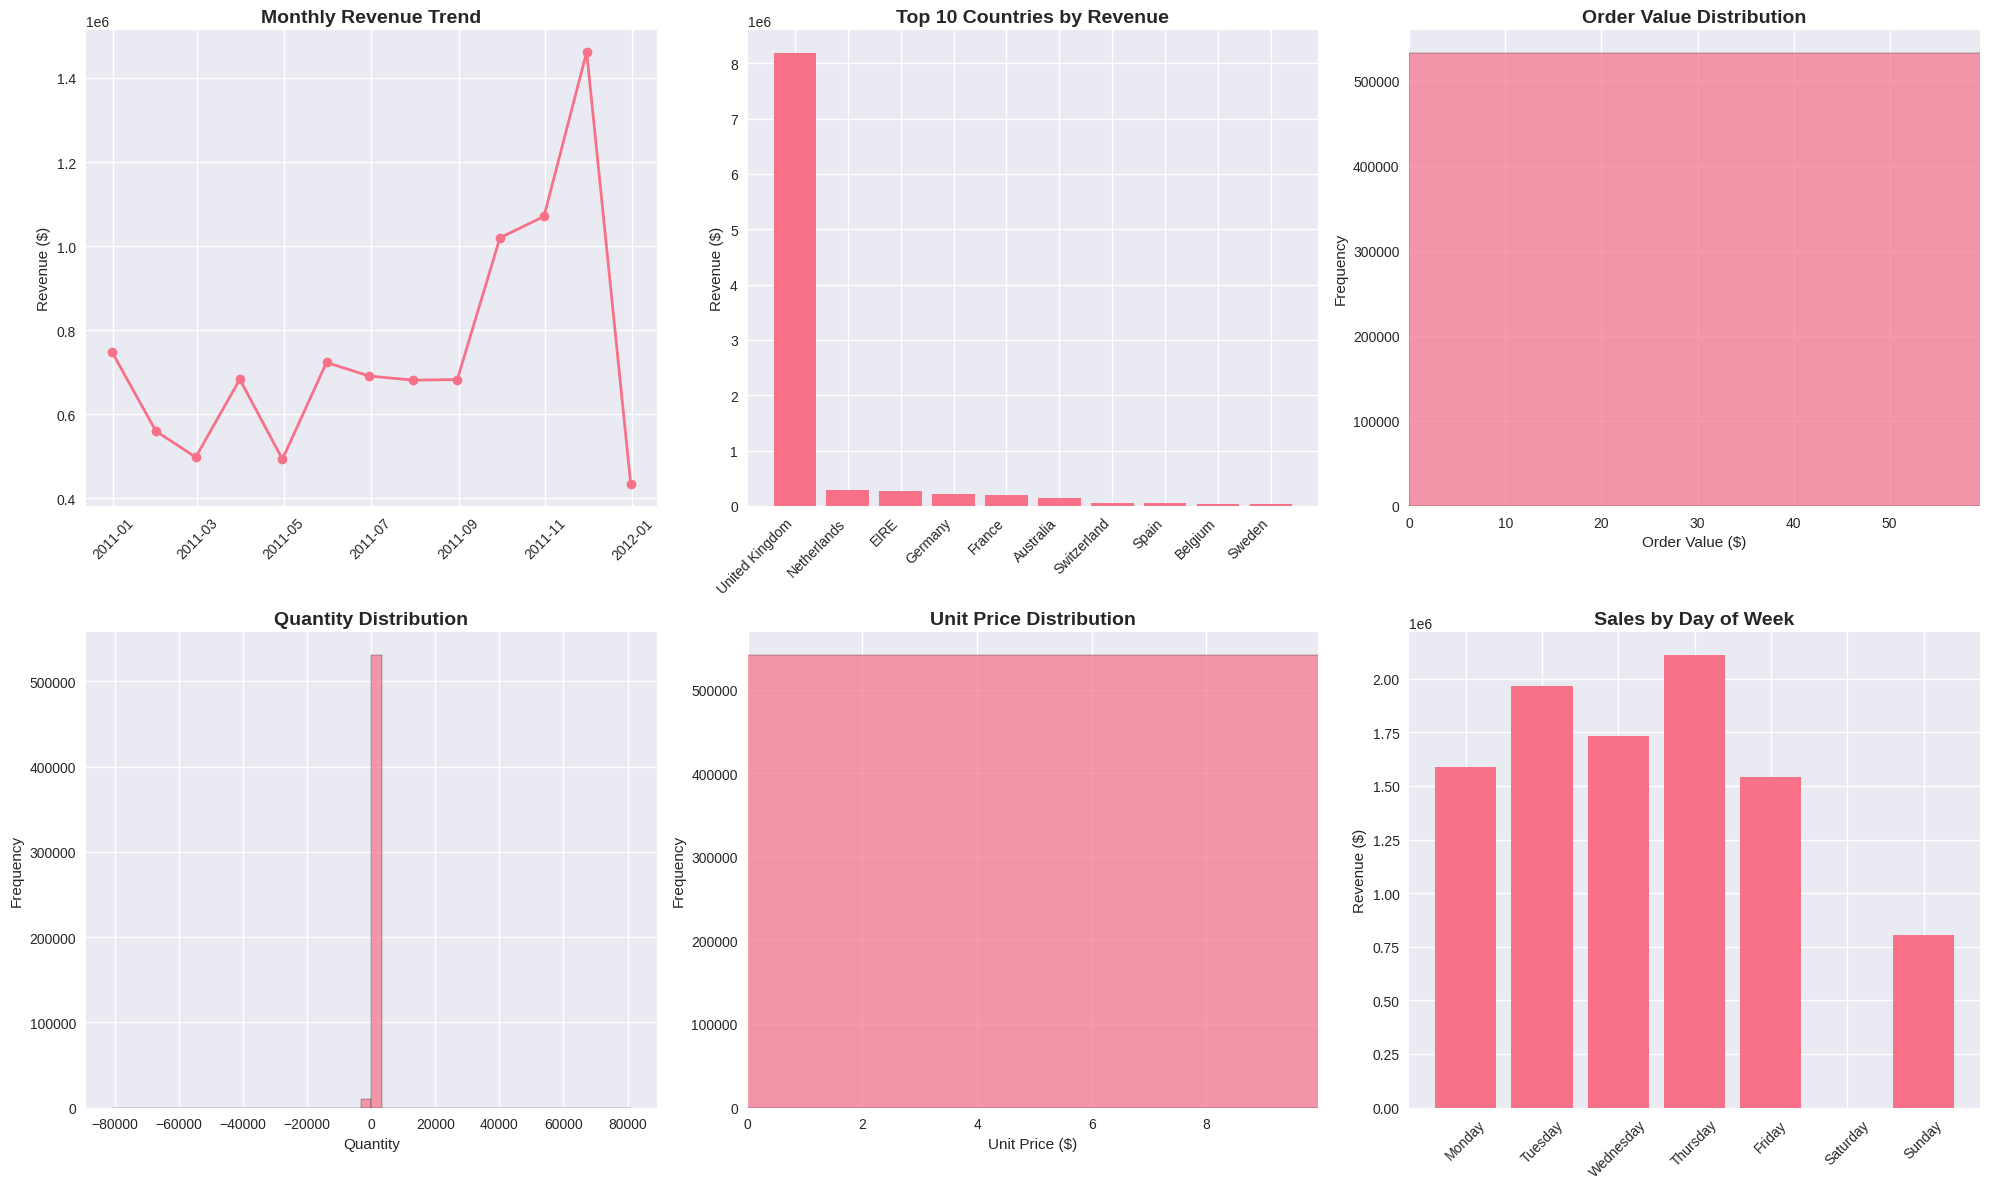

In [ ]:
# 1. Revenue and Sales Trends
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
print("InvoiceDate dtype:", df['InvoiceDate'].dtype)
print("Sample of InvoiceDate values:")
print(df['InvoiceDate'].head())
# Monthly revenue trend
monthly_revenue = df.set_index('InvoiceDate').resample('M')['TotalAmount'].sum()
axes[0,0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2)
axes[0,0].set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)
# Top 10 countries by revenue
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
axes[0,1].bar(range(len(country_revenue)), country_revenue.values)
axes[0,1].set_title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(range(len(country_revenue)))
axes[0,1].set_xticklabels(country_revenue.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Revenue ($)')
# Order value distribution
axes[0,2].hist(df['TotalAmount'], bins=50, edgecolor='black', alpha=0.7)
axes[0,2].set_title('Order Value Distribution', fontsize=14, fontweight='bold')
axes[0,2].set_xlabel('Order Value ($)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_xlim(0, df['TotalAmount'].quantile(0.95))  # Remove extreme outliers
# Quantity distribution
axes[1,0].hist(df['Quantity'], bins=50, edgecolor='black', alpha=0.7)
axes[1,0].set_title('Quantity Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Quantity')
axes[1,0].set_ylabel('Frequency')
# Unit price distribution
axes[1,1].hist(df['UnitPrice'], bins=50, edgecolor='black', alpha=0.7)
axes[1,1].set_title('Unit Price Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Unit Price ($)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_xlim(0, df['UnitPrice'].quantile(0.95))
# Daily sales pattern
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
daily_sales = df.groupby('DayOfWeek')['TotalAmount'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = daily_sales.reindex(day_order)
axes[1,2].bar(range(len(daily_sales)), daily_sales.values)
axes[1,2].set_title('Sales by Day of Week', fontsize=14, fontweight='bold')
axes[1,2].set_xticks(range(len(daily_sales)))
axes[1,2].set_xticklabels(daily_sales.index, rotation=45)
axes[1,2].set_ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

In [ ]:
def calculate_rfm(df, customer_id_col='CustomerID', date_col='InvoiceDate', amount_col='TotalAmount'):
    """
    Calculate RFM (Recency, Frequency, Monetary) metrics
    """

In [ ]:
def segment_customers(rfm_df):
    """
    Segment customers based on RFM scores
    """

In [ ]:
def customer_analysis(df):
    """
    Analyze customer behavior and segmentation
    """
print("\n3. CUSTOMER ANALYSIS:")
# Calculate RFM metrics
rfm_df = calculate_rfm(df)
# Customer segmentation
segment_customers(rfm_df)
 # Top customers
top_customers = df.groupby('CustomerID').agg({
        'TotalAmount': 'sum',
        'InvoiceNo': 'nunique',
        'Quantity': 'sum'
    }).round(2)

top_customers.columns = ['TotalRevenue', 'TotalOrders', 'TotalQuantity']
top_customers = top_customers.sort_values('TotalRevenue', ascending=False)


3. CUSTOMER ANALYSIS:


Plotting customer value distribution

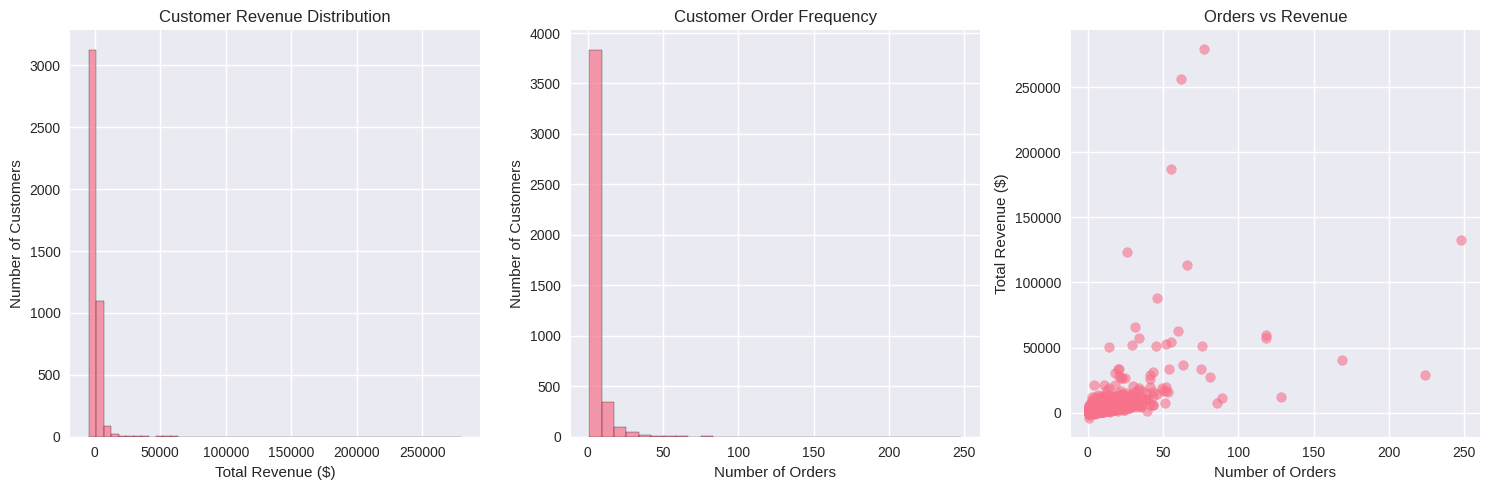

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(top_customers['TotalRevenue'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Customer Revenue Distribution')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
plt.hist(top_customers['TotalOrders'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Customer Order Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
plt.scatter(top_customers['TotalOrders'], top_customers['TotalRevenue'], alpha=0.6)
plt.title('Orders vs Revenue')
plt.xlabel('Number of Orders')
plt.ylabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

FEATURE ENGINEERING
RFM ANALYSIS

In [ ]:
import pandas as pd
import datetime as dt

def calculate_rfm(df, snapshot_date=None):

    # Convert InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Use the provided snapshot date or the latest order date + 1 day
    if snapshot_date is None:
        snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

    # Calculate RFM metrics
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',                                      # Frequency
        'TotalAmount': 'sum'                                           # Monetary
    }).rename(columns={'InvoiceDate': 'recency', 'InvoiceNo': 'frequency', 'TotalAmount': 'monetary'})

    return rfm

TIME-BASED FEATURE ENGINEERING

In [ ]:
def add_time_based_features(df):

    # Convert InvoiceDate to datetime
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

    # Extracting new time-based features
    df['order_month'] = df['InvoiceDate'].dt.month
    df['order_day'] = df['InvoiceDate'].dt.day
    df['order_weekday'] = df['InvoiceDate'].dt.weekday  # Monday=0, Sunday=6
    df['is_weekend'] = df['order_weekday'].apply(lambda x: 1 if x >= 5 else 0)  # Weekend indicator
    df['quarter'] = df['InvoiceDate'].dt.quarter
    df['year'] = df['InvoiceDate'].dt.year

    return df

In [ ]:
# Calculate RFM metrics
rfm = calculate_rfm(df)
print(rfm.head())

# Add time-based features
df_with_time_features = add_time_based_features(df.copy())
print(df_with_time_features.head())

            recency  frequency  monetary
CustomerID                              
12346.0         326          2      0.00
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34   
2 2010-12-01 08:26:00       2.75     17850.0  Uni